# Welcome on board everyone 💅

Hello, hello, hello!

This notebook presents a data analysis project focused on salaries for data science jobs in 2025. It guides you through essential steps, including data preprocessing, data cleaning, insightful data analysis, and compelling data visualization.

A key point to note is that the data used for most of the analysis is specifically filtered for the year 2025. This means it represents a partial-year dataset. Additionally, I've prioritized creating reusable functions throughout, allowing you to easily adapt and apply them for your own interests.

I hope you have fun exploring my project and find it insightful!

I appreciate your engagement! :)

# Import libralies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get overview of the dataset

In [2]:
def show_df(filepath_or_buffer):
    """reads a csv file and displays Dataframe"""
    df = pd.read_csv(filepath_or_buffer)
    return df

house_price = "/kaggle/input/salaries-for-data-science-jobs/salaries.csv"
df = show_df(house_price)
df.sample(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
73371,2024,SE,FT,Engineer,120700,USD,120700,US,0,US,M
118751,2024,EX,FT,Software Engineer,252000,USD,252000,US,0,US,M
38481,2025,SE,FT,Software Engineer,143896,USD,143896,US,0,US,M
57479,2025,SE,FT,Analyst,126000,USD,126000,US,100,US,M
86898,2024,SE,FT,Data Engineer,205700,USD,205700,US,100,US,M


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141566 entries, 0 to 141565
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           141566 non-null  int64 
 1   experience_level    141566 non-null  object
 2   employment_type     141566 non-null  object
 3   job_title           141566 non-null  object
 4   salary              141566 non-null  int64 
 5   salary_currency     141566 non-null  object
 6   salary_in_usd       141566 non-null  int64 
 7   employee_residence  141566 non-null  object
 8   remote_ratio        141566 non-null  int64 
 9   company_location    141566 non-null  object
 10  company_size        141566 non-null  object
dtypes: int64(4), object(7)
memory usage: 11.9+ MB


In [4]:
df.shape

(141566, 11)

In [5]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [6]:
df.duplicated().sum()

73678

## Get unique values in a column

In [7]:
def unique_values(dataframe, column_name):
    """
    Returns the unique values in a given column, with formatting for string values.
    
    Parameters:
    - dataframe: pandas DataFrame
    - column_name: string name of the column to analyze
    
    Returns:
    - List of unique values
    """
    if dataframe[column_name].dtype == 'string':
        cleaned_col = dataframe[column_name].str.strip().str.upper()
    else:
        cleaned_col = dataframe[column_name]

    unique_vals = cleaned_col.unique()

    print(f"Unique values in '{column_name}':")
    print(unique_vals)
    print(f"Total: {len(unique_vals)} unique values\n")

    return unique_vals

In [8]:
unique_values(df, 'work_year')
unique_values(df, 'experience_level')
unique_values(df, 'salary_currency')
unique_values(df, 'company_location')
unique_values(df, 'company_size')
unique_values(df, 'remote_ratio')

Unique values in 'work_year':
[2025 2024 2023 2022 2020 2021]
Total: 6 unique values

Unique values in 'experience_level':
['EN' 'SE' 'MI' 'EX']
Total: 4 unique values

Unique values in 'salary_currency':
['GBP' 'USD' 'EUR' 'CAD' 'INR' 'PLN' 'NOK' 'MXN' 'CHF' 'PHP' 'JPY' 'SGD'
 'HUF' 'AUD' 'TWD' 'BRL' 'CZK' 'ZAR' 'DKK' 'ILS' 'TRY' 'SEK' 'NZD' 'HKD'
 'THB' 'CLP']
Total: 26 unique values

Unique values in 'company_location':
['GB' 'US' 'CA' 'FR' 'DE' 'SK' 'PT' 'IN' 'CL' 'NL' 'AU' 'MY' 'BR' 'AT'
 'SV' 'CO' 'DO' 'AR' 'MX' 'GT' 'CR' 'LT' 'ES' 'LV' 'IE' 'BE' 'ZA' 'PL'
 'NO' 'FI' 'EE' 'PH' 'EG' 'JO' 'CY' 'NZ' 'UA' 'CH' 'TH' 'JM' 'JP' 'MT'
 'MK' 'SI' 'HK' 'LS' 'PE' 'SG' 'IT' 'HU' 'RO' 'PA' 'LU' 'DZ' 'GR' 'KE'
 'CD' 'SE' 'KR' 'TW' 'CZ' 'TR' 'DK' 'AE' 'BG' 'ID' 'RS' 'PR' 'EC' 'XK'
 'ZM' 'AM' 'IL' 'LB' 'NG' 'HR' 'PK' 'HN' 'VE' 'AS' 'SA' 'OM' 'BA' 'VN'
 'GI' 'MU' 'RU' 'QA' 'GH' 'AD' 'CF' 'IR' 'BS' 'IQ' 'CN' 'MD']
Total: 96 unique values

Unique values in 'company_size':
['M' 'L' 'S']
Total: 3 uniq

array([  0, 100,  50])

In [9]:
unique_values(df, 'job_title')

Unique values in 'job_title':
['Data Quality Analyst' 'Applied Scientist' 'Data Scientist' 'Manager'
 'Software Engineer' 'Machine Learning Engineer'
 'Machine Learning Scientist' 'Analyst' 'Power BI Developer' 'Engineer'
 'Research Assistant' 'Director' 'AI Engineer' 'Tech Lead' 'Data Lead'
 'Consultant' 'Data Manager' 'Developer' 'Solutions Architect'
 'Head of Data' 'Data Analyst' 'Analytics Engineer'
 'Data Visualization Engineer' 'Product Owner' 'Data Governance'
 'Data Specialist' 'Architect' 'Product Manager' 'Data Engineer'
 'Data Architect' 'Quantitative Researcher' 'Researcher' 'Staff Engineer'
 'Engineering Manager' 'Solution Architect' 'DevOps Engineer' 'Associate'
 'Site Reliability Engineer' 'Research Scientist' 'Product Analyst'
 'Principal Researcher' 'AIRS Solutions Specialist' 'Data Product Manager'
 'Data Management Analyst' 'Full Stack Developer'
 'Software Development Engineer' 'Artificial Intelligence Engineer'
 'Platform Engineer' 'Full Stack Engineer' 'Systems E

array(['Data Quality Analyst', 'Applied Scientist', 'Data Scientist',
       'Manager', 'Software Engineer', 'Machine Learning Engineer',
       'Machine Learning Scientist', 'Analyst', 'Power BI Developer',
       'Engineer', 'Research Assistant', 'Director', 'AI Engineer',
       'Tech Lead', 'Data Lead', 'Consultant', 'Data Manager',
       'Developer', 'Solutions Architect', 'Head of Data', 'Data Analyst',
       'Analytics Engineer', 'Data Visualization Engineer',
       'Product Owner', 'Data Governance', 'Data Specialist', 'Architect',
       'Product Manager', 'Data Engineer', 'Data Architect',
       'Quantitative Researcher', 'Researcher', 'Staff Engineer',
       'Engineering Manager', 'Solution Architect', 'DevOps Engineer',
       'Associate', 'Site Reliability Engineer', 'Research Scientist',
       'Product Analyst', 'Principal Researcher',
       'AIRS Solutions Specialist', 'Data Product Manager',
       'Data Management Analyst', 'Full Stack Developer',
       'Softwa

In [10]:
df["company_location"].value_counts().head(10)

company_location
US    126870
CA      5678
GB      3923
AU       548
NL       432
DE       412
FR       399
LT       354
AT       331
ES       287
Name: count, dtype: int64

# Data Preprocessing

In [11]:
def preprocess(filename = house_price):
    """prepares and transforms dataframe"""

    # change data types
    dtype_mapper = {"experience_level" : "string",
                    "employment_type" : "string",
                    "job_title" : "string",
                    "salary_currency" : "string",
                    "employee_residence" : "string",
                    "company_location" : "string",
                    "company_size" : "string"}
    
    # read the data file
    df = (pd.read_csv(filename, dtype=dtype_mapper)
        .drop("salary", axis = 1))

    # Standardizes currency values
    df["salary_currency"] = df["salary_currency"].str.strip().str.upper()

    # Keeps only rows where currency is USD
    df = df[df["salary_currency"] == "USD"]

    # removes duplicated rows
    df = df.drop_duplicates()

    return df
    
sa = preprocess()
sa.sample(3)

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
30000,2025,MI,FT,Manager,USD,92560,US,0,US,M
117588,2024,SE,FT,Research Analyst,USD,96600,US,0,US,M
7281,2025,MI,FT,Manager,USD,93400,US,0,US,M


In [12]:
# recheck data type and duplicated rows
sa.info()
print(f"There are {sa.duplicated().sum()} of duplicated rows")

<class 'pandas.core.frame.DataFrame'>
Index: 62247 entries, 2 to 141564
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           62247 non-null  int64 
 1   experience_level    62247 non-null  string
 2   employment_type     62247 non-null  string
 3   job_title           62247 non-null  string
 4   salary_currency     62247 non-null  string
 5   salary_in_usd       62247 non-null  int64 
 6   employee_residence  62247 non-null  string
 7   remote_ratio        62247 non-null  int64 
 8   company_location    62247 non-null  string
 9   company_size        62247 non-null  string
dtypes: int64(3), string(7)
memory usage: 5.2 MB
There are 0 of duplicated rows


In [13]:
sa.shape

(62247, 10)

# The Main Reveal 🎬

## General Descriptive Insights

## 1. Top 10 average highest and lowest paid data science jobs in 2025 (globally) 🌏

In [14]:
def paid_summary(dataframe, top_n = 10, ascending=False):
    """
    Sorts a salary summary DataFrame by a specified column and prints the top N job titles.
    Args:
        df_summary (pd.DataFrame): The DataFrame containing aggregated county data
                                   (e.g., from a groupby.sum()).
        column_name (str): The name of the column to sort by.
        top_n (int, optional): The number of top records to display. Defaults to 10.
    """
    # Keeps only work_year == 2025
    df_2025 = dataframe[dataframe["work_year"] == 2025]
    
    salary_summary = df_2025.groupby("job_title")["salary_in_usd"].mean().round(2)
    sorted_df = salary_summary.sort_values(ascending = ascending)

    # Display result
    label = "lowest" if ascending else "highest"
    print(f"\nTop {top_n} {label} paid job titles in USD for 2025:")
    print(sorted_df.head(top_n).to_string())

In [15]:
paid_summary(sa, top_n=10, ascending=False)
paid_summary(sa, top_n=10, ascending=True)


Top 10 highest paid job titles in USD for 2025:
job_title
Research Team Lead                450000.00
Head of Applied AI                278500.00
Director of Data                  270000.00
Head of AI                        263937.58
AIRS Solutions Specialist         263250.00
Director of Machine Learning      261650.00
Director of Product Management    261555.25
Head of Data                      257485.97
Enterprise Account Executive      249416.67
Engineering Manager               248750.65

Top 10 lowest paid job titles in USD for 2025:
job_title
Quantitative Risk Analyst    18000.00
QA Tutor Reviewer            24000.00
Clinical Data Operator       36000.00
Clinical Aide                37333.33
AI Content Writer            40506.67
Data Operator                42000.00
Data Integration Analyst     49000.00
Research Assistant           49400.59
Admin & Data Analyst         52000.00
Data & Analytics Analyst     55000.00


## 2. Top 10 average highest and lowest paid data science jobs in 2025 (USA) 🇺🇸

In [16]:
def paid_summary(dataframe, headquater, top_n = 10, ascending=False):
    """
    Sorts a salary summary DataFrame by a specified column and prints the top N job titles.
    Args:
        df_summary (pd.DataFrame): The DataFrame containing aggregated county data
                                   (e.g., from a groupby.sum()).
        column_name (str): The name of the column to sort by.
        top_n (int, optional): The number of top records to display. Defaults to 10.
    """
    # Keeps only work_year == 2025 & company_location == US
    df_2025 = dataframe[
                (dataframe["work_year"] == 2025) & 
                (dataframe["company_location"] == headquater)]    
    
    salary_summary = df_2025.groupby("job_title")["salary_in_usd"].mean().round(2)
    sorted_df = salary_summary.sort_values(ascending = ascending)

    # Display result
    label = "lowest" if ascending else "highest"
    print(f"\nTop {top_n} {label} paid job titles in USD for 2025 (Location: {headquater}):")
    print(sorted_df.head(top_n).to_string())

In [17]:
paid_summary(sa, "US", top_n=10, ascending = False)
paid_summary(sa, "US", top_n=10, ascending = True)


Top 10 highest paid job titles in USD for 2025 (Location: US):
job_title
Research Team Lead                450000.00
Director of Data                  270000.00
Director of Product Management    263819.06
AIRS Solutions Specialist         263250.00
Director of Machine Learning      261650.00
Head of Applied AI                260000.00
Head of Data                      259758.44
Head of AI                        256342.76
Engineering Manager               251380.77
Head of Machine Learning          247750.00

Top 10 lowest paid job titles in USD for 2025 (Location: US):
job_title
Clinical Data Operator       36000.00
Clinical Aide                37333.33
AI Content Writer            40506.67
Data Operator                42000.00
Data Integration Analyst     49000.00
Research Assistant           50674.94
Admin & Data Analyst         52000.00
Trainee                      55000.00
Data Integrity Specialist    64000.00
Research Specialist          64100.00


## 3. Top 10 average highest and lowest paid data science jobs in 2025 (UK) 🇬🇧

In [18]:
paid_summary(sa, "GB", top_n=10, ascending = False)
paid_summary(sa, "GB", top_n=10, ascending = True)


Top 10 highest paid job titles in USD for 2025 (Location: GB):
job_title
Data Analysis                218000.0
Systems Engineer             215000.0
Manager                      204037.5
Machine Learning Engineer    204000.0
Quant Options Trader         200000.0
Research Scientist           190500.0
AI Lead                      186550.0
Data Architect               183350.0
Sales Engineer               180000.0
Data Engineer                175000.0

Top 10 lowest paid job titles in USD for 2025 (Location: GB):
job_title
AI Programmer         75000.00
Associate             80000.00
Data Analyst         100401.00
AI Engineer          106666.67
Director             112827.50
Data Integrator      123800.00
Data Governance      130000.00
Analyst              132805.67
Engineer             155958.62
Software Engineer    157000.00


## 4. Average salary for each experience level

- EN: Entry-level / Junior
- MI: Mid-level / Intermediate
- SE: Senior-level
- EX: Executive / Director

In [19]:
def avg_salary_by_experience(dataframe, year=None, country=None):
    """
    Returns average salary in USD grouped by experience level.

    Parameters:
    - dataframe (pd.DataFrame): Your salary DataFrame
    - year (int, optional): Filter for a specific year
    - country (str, optional): Filter for a specific company location (e.g., "US")
    """
    df_filtered = dataframe.copy()

    # Filter by year
    if year is not None:
        df_filtered = df_filtered[df_filtered["work_year"] == year]

    # Filter by country
    if country is not None:
        df_filtered = df_filtered[df_filtered["company_location"] == country]

    result = (df_filtered
              .groupby("experience_level")["salary_in_usd"]
              .mean()
              .round(2)
              .sort_values(ascending=False)
             )

    print(f"\nAverage salary by experience level" +
          (f" in {country}" if country else "") +
          (f" for {year}" if year else "") + ":\n")

    return result

## 5. Average salary for each experience level (Globally) 🌏

In [20]:
avg_salary_by_experience(sa, year=2025)


Average salary by experience level for 2025:



experience_level
EX    204521.05
SE    173691.06
MI    142884.29
EN    104406.70
Name: salary_in_usd, dtype: float64

## 6. Average salary for each experience level (US) 🇺🇸

In [21]:
avg_salary_by_experience(sa, year=2025, country="US")


Average salary by experience level in US for 2025:



experience_level
EX    204592.94
SE    176786.49
MI    145575.16
EN    107007.79
Name: salary_in_usd, dtype: float64

## 7. Average salary for each experience level (GB) 🇬🇧

In [22]:
avg_salary_by_experience(sa, year=2025, country="GB")


Average salary by experience level in GB for 2025:



experience_level
MI    185793.75
EX    162643.67
SE    149621.86
EN     97950.73
Name: salary_in_usd, dtype: float64

## 8. Job Title Trends

**Most common jobs**

In [23]:
def most_common_jobs(dataframe, top_n=10):
    """Returns the most common job titles and their counts."""
    
    job_counts = dataframe["job_title"].value_counts().head(top_n)
    
    print(f"\nTop {top_n} most common job titles:")
    
    return job_counts

In [24]:
most_common_jobs(sa, top_n=10)


Top 10 most common job titles:


job_title
Data Scientist               6224
Data Engineer                6006
Data Analyst                 5395
Software Engineer            4362
Engineer                     3874
Manager                      3261
Machine Learning Engineer    3112
Analyst                      2404
Research Scientist           1266
Product Manager              1214
Name: count, dtype: Int64

## 9. Average salary for most common jobs

In [25]:
def avg_salary_for_common_jobs(dataframe, top_n=10):
    """Shows average salary of the most common job titles."""
    
    common_jobs = dataframe["job_title"].value_counts().head(top_n).index.tolist()

    avg_salary = (dataframe[dataframe["job_title"].isin(common_jobs)]
                  .groupby("job_title")["salary_in_usd"]
                  .mean()
                  .round(2)
                  .sort_values(ascending=False))

    print(f"\nAverage salaries for the top {top_n} most common job titles:")
    
    return avg_salary

In [26]:
avg_salary_for_common_jobs(sa, top_n=10)


Average salaries for the top 10 most common job titles:


job_title
Machine Learning Engineer    196514.19
Research Scientist           194893.15
Product Manager              190210.36
Software Engineer            183679.67
Manager                      171742.01
Engineer                     170290.60
Data Scientist               160027.96
Data Engineer                154541.41
Analyst                      116647.94
Data Analyst                 110948.70
Name: salary_in_usd, dtype: float64

## 10. Career entry advice

In [27]:
def job_entry(dataframe, year=None, country=None, top_n=10):
    """Returns top N best-paying entry-level jobs by average salary."""

    df_filtered = dataframe.copy()

    # Filter only entry-level jobs
    df_filtered = df_filtered[df_filtered["experience_level"] == "EN"]

    # Filter by year
    if year is not None:
        df_filtered = df_filtered[df_filtered["work_year"] == year]

    # Filter by company location
    if country is not None:
        df_filtered = df_filtered[df_filtered["company_location"] == country]

    # Group by job title and calculate average salary
    job_avg_salary = (df_filtered
                      .groupby("job_title")["salary_in_usd"]
                      .mean()
                      .round(2)
                      .sort_values(ascending=False)
                      .head(top_n))

    print(f"\nTop {top_n} best-paying entry-level jobs" +
          (f" in {country}" if country else "") +
          (f" for {year}" if year else "") + ":\n")

    return job_avg_salary


In [28]:
# Global (all years)
job_entry(sa, top_n=10)


Top 10 best-paying entry-level jobs:



job_title
Engineering Manager                350933.33
Head of Data                       240500.00
Algorithm Developer                212500.00
Director                           204718.00
AI Researcher                      203643.64
Quantitative Researcher            193125.00
Software Architect                 190000.00
Research Scientist                 183404.07
Machine Learning Model Engineer    180000.00
Architect                          170837.50
Name: salary_in_usd, dtype: float64

In [29]:
# recheck for correctness
df_filtered = sa.copy()
sa[(sa["job_title"] == "Engineering Manager") & (sa["experience_level"] == "EN")].sample(3)

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
17610,2025,EN,FT,Engineering Manager,USD,425000,US,0,US,M
56104,2025,EN,FT,Engineering Manager,USD,193600,US,0,US,M
56103,2025,EN,FT,Engineering Manager,USD,242000,US,0,US,M


In [30]:
# In the US, in 2025
job_entry(sa, year=2025, country="US", top_n=10)


Top 10 best-paying entry-level jobs in US for 2025:



job_title
Engineering Manager            350933.33
Head of Data                   240500.00
Algorithm Developer            212500.00
Machine Learning Researcher    212500.00
Director                       204718.00
Quantitative Researcher        199166.67
AI Researcher                  197510.00
Software Architect             190000.00
Research Scientist             183821.21
Research Engineer              178589.40
Name: salary_in_usd, dtype: float64

In [31]:
# recheck for correctness
df_filtered = sa.copy()
sa[(sa["job_title"] == "Data Analytics Manager") & (sa["experience_level"] == "EN")].sample(3)

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
48050,2025,EN,FT,Data Analytics Manager,USD,158000,US,0,US,M
48049,2025,EN,FT,Data Analytics Manager,USD,190000,US,0,US,M
129572,2024,EN,FT,Data Analytics Manager,USD,27000,IN,100,AS,M


## 11. Job Salary and remote ratio

In [32]:
def salary_remote(dataframe, ratio_rate, year=None, country=None, top_n=10):
    """
    Sorts a county summary DataFrame by a specified column and prints the top N counties.
    """

    df_ratio_sal = dataframe.copy()

    # Filter by remote ratio
    df_ratio_sal = df_ratio_sal[df_ratio_sal["remote_ratio"] == ratio_rate]

    # Filter by year
    if year is not None:
        df_ratio_sal = df_ratio_sal[df_ratio_sal["work_year"] == year]

    # Filter by company location
    if country is not None:
        df_ratio_sal = df_ratio_sal[df_ratio_sal["company_location"] == country]

    # Group by job title and calculate average salary
    job_avg_salary = (df_ratio_sal
                      .groupby("job_title")["salary_in_usd"]
                      .mean()
                      .round(2)
                      .sort_values(ascending=False)
                      .head(top_n))

    print(f"\nTop {top_n} best-paying jobs" +
          (f" in {country}" if country else "") +
            (f" remote ratio {ratio_rate}" if ratio_rate else "") + ":\n")

    return job_avg_salary

**Top 10 Highest paid data science jobs with 100 remote working (Globally)**

In [33]:
salary_remote(sa, ratio_rate = 100, year = 2025, top_n=10)


Top 10 best-paying jobs remote ratio 100:



job_title
Principal Researcher              380000.00
Director of Machine Learning      297037.50
Head of Applied AI                287750.00
Head of Data                      278260.94
Head of AI                        276250.00
Director of Data                  262500.00
Director of Product Management    260000.00
Enterprise Account Executive      253166.67
Engineering Manager               238809.19
Data Operations Lead              220000.00
Name: salary_in_usd, dtype: float64

**Top 10 Highest paid data science jobs with no remote working (Globally)**

In [34]:
salary_remote(sa, ratio_rate = 0, year = 2025, top_n=10)


Top 10 best-paying jobs:



job_title
Research Team Lead                450000.00
Director of Data                  277500.00
AIRS Solutions Specialist         263250.00
Director of Product Management    261944.06
Head of Applied AI                260000.00
Head of AI                        259997.60
Engineering Manager               252232.69
Head of Data                      251355.66
Head of Machine Learning          247750.00
Machine Learning Architect        246320.00
Name: salary_in_usd, dtype: float64

# Visualisations 👀

## 1. Company size distribution


Histogram for work_year == 2025 only:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


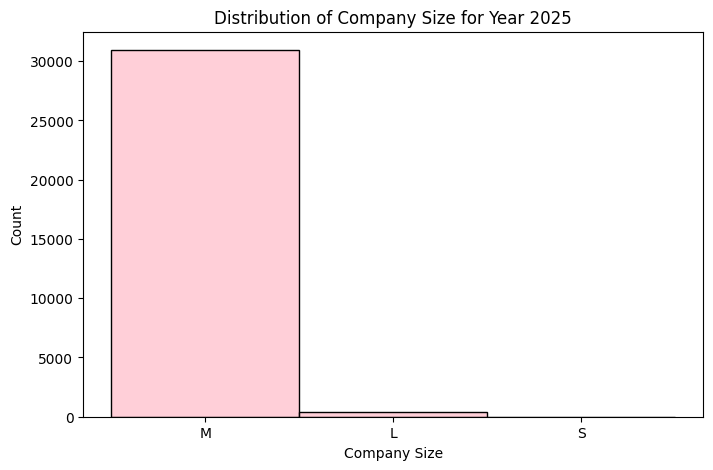

In [35]:
sa_2025 = sa[sa["work_year"] == 2025].copy()

if sa_2025.empty:
    print("No data available for work_year == 2025 to plot company_size.")
else:
    print("\nHistogram for work_year == 2025 only:")
    plt.figure(figsize=(8, 5))
    sns.histplot(sa_2025["company_size"], color='pink')
    plt.title("Distribution of Company Size for Year 2025")
    plt.xlabel("Company Size")
    plt.ylabel("Count")  
    plt.show()

## 2. Salary Distribution


Histogram for work_year == 2025 only:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


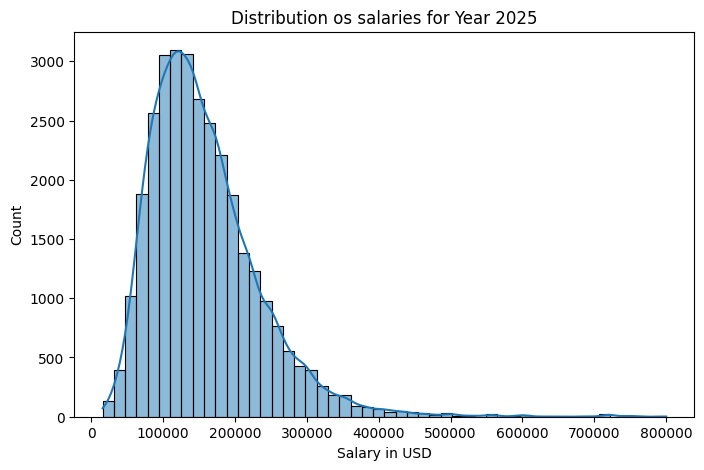

In [36]:
sa_2025 = sa[sa["work_year"] == 2025].copy()
if sa_2025.empty:
    print("No data available for work_year == 2025 to plot company_size.")
else:
    print("\nHistogram for work_year == 2025 only:")
    plt.figure(figsize=(8, 5))
    sns.histplot(sa_2025["salary_in_usd"], bins=50, kde=True)
    plt.title("Distribution os salaries for Year 2025")
    plt.xlabel("Salary in USD")
    plt.ylabel("Count")  
    plt.show()

## 3. Salary by Experience Level

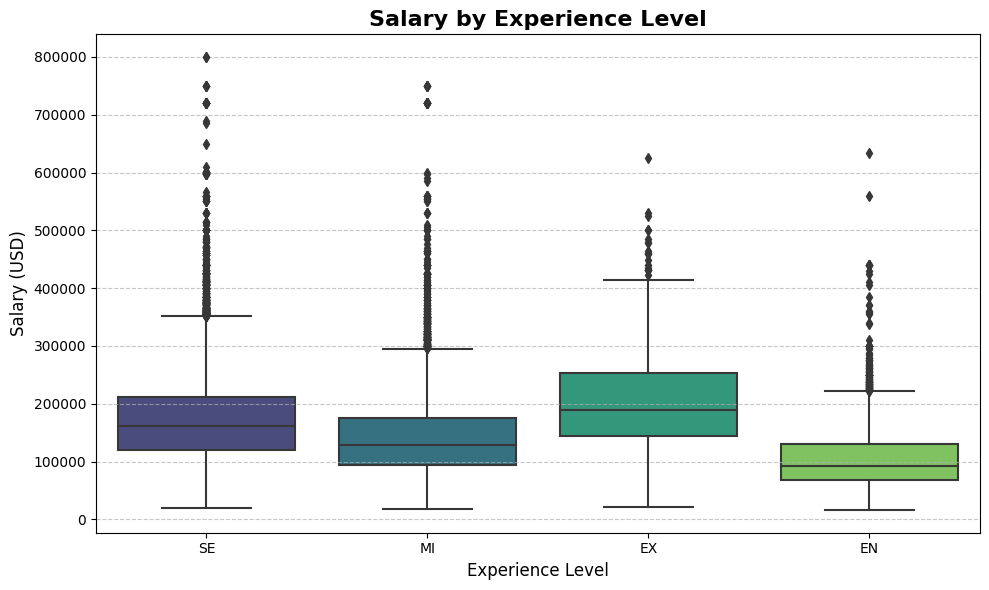

In [37]:
if sa_2025.empty:
    print("No data available in sa_2025 to plot.")
else:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=sa_2025, x="experience_level", y="salary_in_usd", palette="viridis")
    plt.title("Salary by Experience Level", fontsize=16, fontweight='bold')
    plt.xlabel("Experience Level", fontsize=12)
    plt.ylabel("Salary (USD)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 4. Average Salary by Country

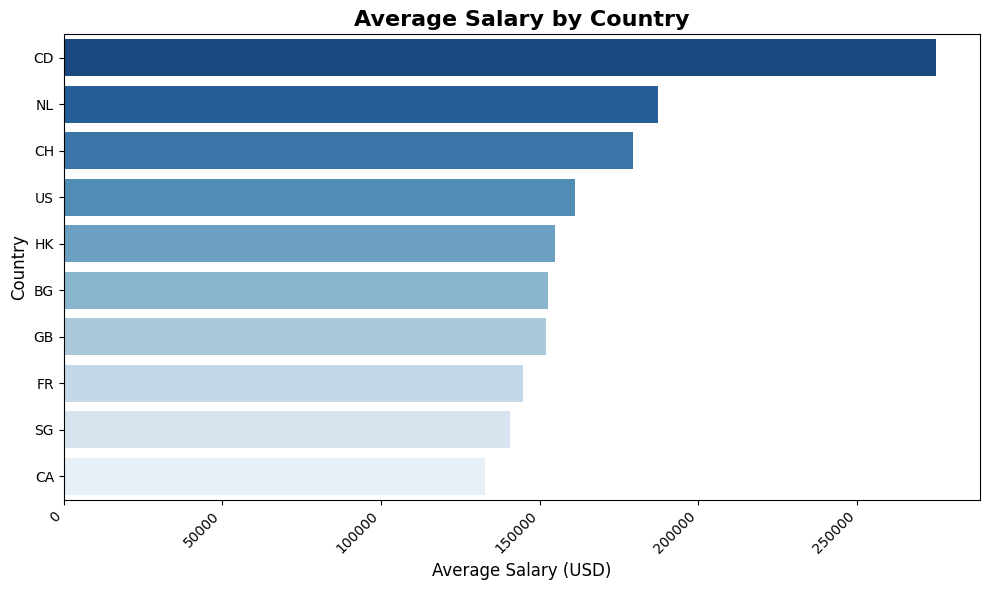

In [38]:
if sa_2025.empty:
    print("No data available in sa_2025 to plot.")
else:
    top_countries = sa_2025.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)
    if top_countries.empty:
        print("No top countries found to plot after aggregation.")
    else:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_countries.values, y=top_countries.index, palette="Blues_r")
        plt.title("Average Salary by Country", fontsize=16, fontweight='bold')
        plt.xlabel("Average Salary (USD)", fontsize=12)
        plt.ylabel("Country", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [39]:
paid_summary(sa, "CD", top_n=10, ascending = False)
paid_summary(sa, "CD", top_n=10, ascending = True)


Top 10 highest paid job titles in USD for 2025 (Location: CD):
job_title
Engineer    275000.0

Top 10 lowest paid job titles in USD for 2025 (Location: CD):
job_title
Engineer    275000.0


In [40]:
paid_summary(sa, "NL", top_n=10, ascending = False)
paid_summary(sa, "NL", top_n=10, ascending = True)


Top 10 highest paid job titles in USD for 2025 (Location: NL):
job_title
Machine Learning Engineer    212500.0
Engineer                     197500.0
Manager                      141900.0

Top 10 lowest paid job titles in USD for 2025 (Location: NL):
job_title
Manager                      141900.0
Engineer                     197500.0
Machine Learning Engineer    212500.0


In [41]:
paid_summary(sa, "CH", top_n=10, ascending = False)
paid_summary(sa, "CH", top_n=10, ascending = True)


Top 10 highest paid job titles in USD for 2025 (Location: CH):
job_title
Quantitative Researcher    187500.0
Software Engineer          171500.0

Top 10 lowest paid job titles in USD for 2025 (Location: CH):
job_title
Software Engineer          171500.0
Quantitative Researcher    187500.0


## 5. Heatmap: Salary vs Experience vs Company Size

Cross-dimension analysis to find hot salary spots

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


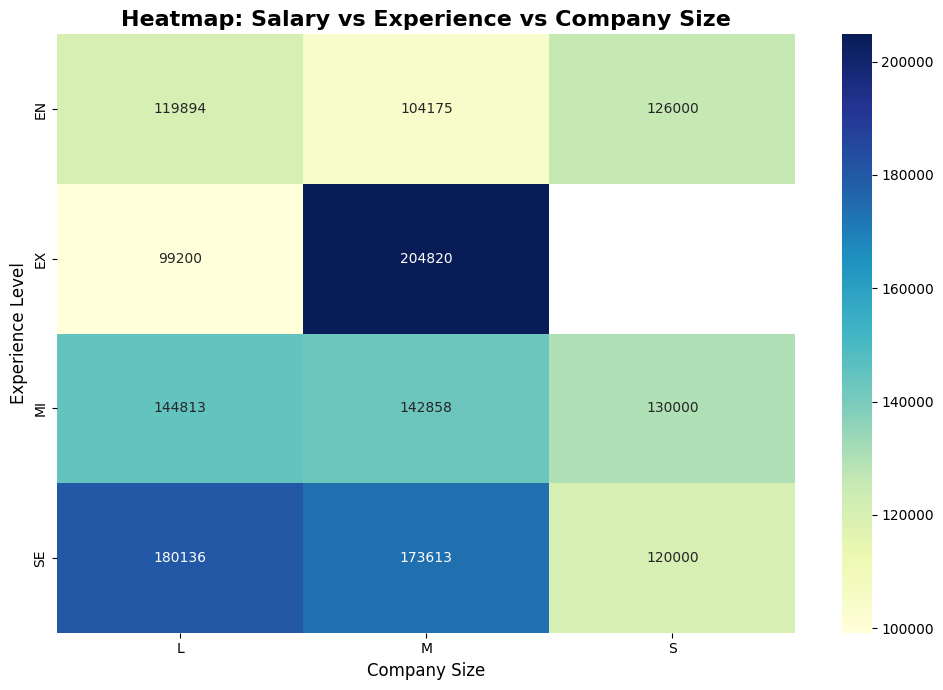

In [42]:
if sa_2025.empty:
    print("No data available in sa_2025 to create heatmap.")
else:
    pivot = sa_2025.pivot_table(index="experience_level", columns="company_size", values="salary_in_usd", aggfunc="mean")
    if pivot.empty:
        print("Pivot table is empty. No combinations of experience_level and company_size found with data.")
    else:
        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
        plt.title("Heatmap: Salary vs Experience vs Company Size", fontsize=16, fontweight='bold')

        plt.xlabel("Company Size", fontsize=12)
        plt.ylabel("Experience Level", fontsize=12)
        plt.tight_layout()
        plt.show()

## 6. Bar Plot of Top 10 Highest Paid Job Titles

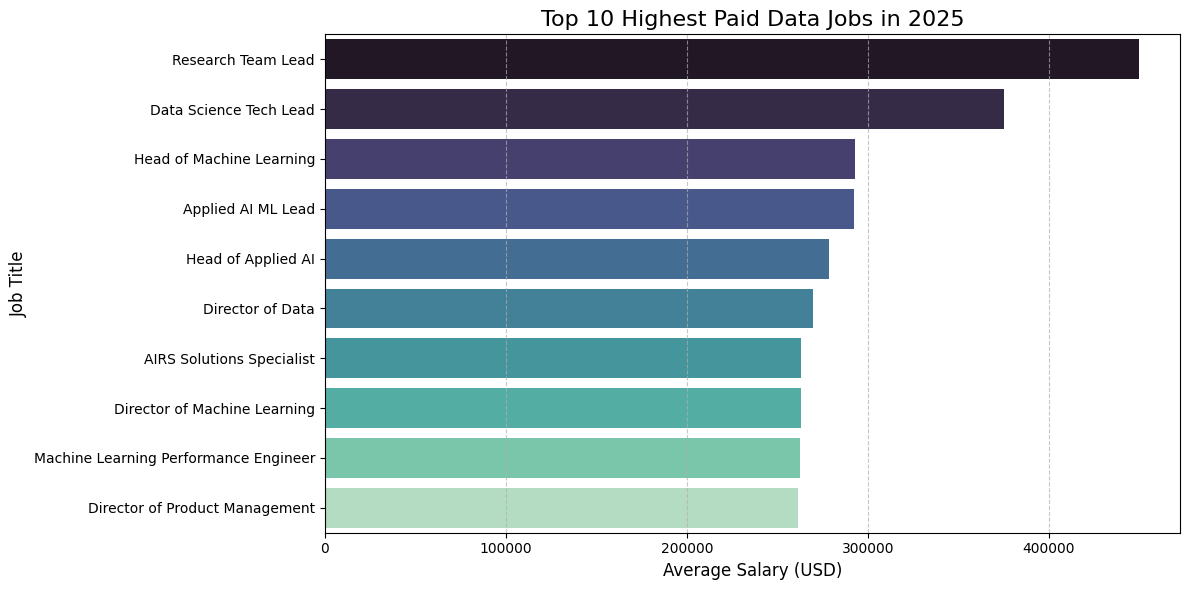

In [43]:
# Group by job title and get average salary
top_jobs = (sa.groupby("job_title")["salary_in_usd"]
              .mean()
              .sort_values(ascending=False)
              .head(10)
              .round(2))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette="mako")

plt.title("Top 10 Highest Paid Data Jobs in 2025", fontsize=16)
plt.xlabel("Average Salary (USD)", fontsize=12)
plt.ylabel("Job Title", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Remote Work & Salary

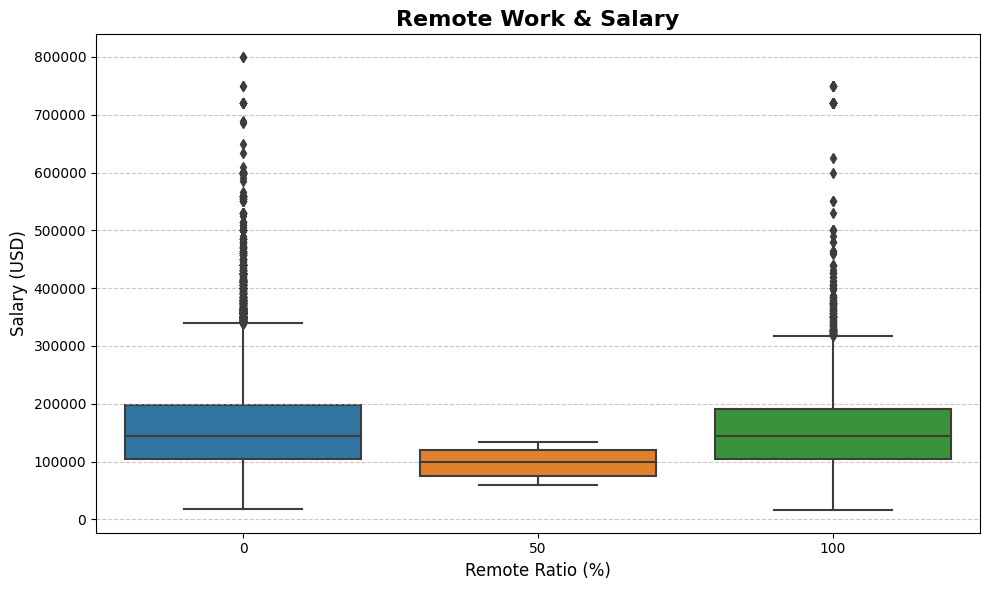

In [44]:
if sa_2025.empty:
    print("No data available in sa_2025 to plot.")
else:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=sa_2025, x="remote_ratio", y="salary_in_usd")
    plt.title("Remote Work & Salary", fontsize=16, fontweight='bold')
    plt.xlabel("Remote Ratio (%)", fontsize=12)
    plt.ylabel("Salary (USD)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## 8.Salary Over Time by Experience Level

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

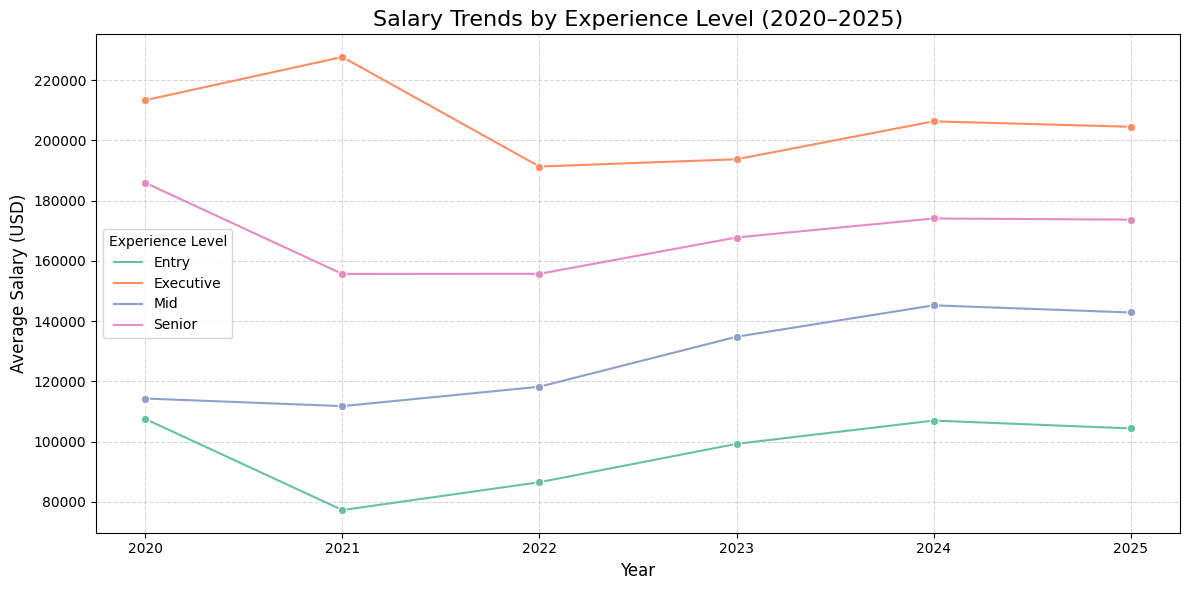

In [45]:
salary_over_time = (
    sa.groupby(["work_year", "experience_level"])["salary_in_usd"]
    .mean()
    .reset_index()
)

# map experience levels to full names for clarity
exp_map = {"EN": "Entry", "MI": "Mid", "SE": "Senior", "EX": "Executive"}
salary_over_time["experience_level"] = salary_over_time["experience_level"].map(exp_map)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=salary_over_time,
    x="work_year",
    y="salary_in_usd",
    hue="experience_level",
    marker="o",
    palette="Set2"
)

plt.title("Salary Trends by Experience Level (2020–2025)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.xticks(salary_over_time["work_year"].unique())
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Experience Level")
plt.tight_layout()
plt.show()

# Prdiction Models

**Preview the original dataset**

In [46]:
df.sample(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
51222,2025,SE,FT,Data Engineer,104650,USD,104650,US,0,US,M
19294,2025,SE,FT,Architect,249000,USD,249000,US,0,US,M
131493,2023,SE,FT,Data Scientist,188200,USD,188200,US,0,US,M
132299,2023,SE,FT,Data Engineer,115000,USD,115000,US,0,US,M
55200,2025,MI,FT,AI Engineer,80000,USD,80000,US,100,US,M


## Data Preporcessing for ML

In [47]:
def preprocess(filename="house_price.csv"):
    """
    prepares and transforms dataframe
    Tranformation applied
    - change data types
    - drop "salary" column
    - strip "salary_currency" col
    - OHE
    - Frequency feature engineering
    - reorder the target col
    - drop duplicated rows
    - log transform salary
    """

    # change data types
    dtype_mapper = {"experience_level" : "category",
                    "employment_type" : "category",
                    "job_title" : "string", # Job title remains as string for frequency encoding
                    "salary_currency" : "category",
                    "employee_residence" : "string",
                    "company_location" : "string",
                    "company_size" : "category"}
    
    # read the data file
    df = (pd.read_csv(filename, dtype=dtype_mapper)
        .drop("salary", axis = 1))

    # Standardizes currency values
    df["salary_currency"] = df["salary_currency"].str.strip().str.upper()

    # Keeps only rows where currency is USD
    df = df[df["salary_currency"] == "USD"]

    # removes duplicated rows
    df = df.drop_duplicates()

    # drop a column
    df.drop("salary_currency", axis=1, inplace=True)
    
    # Feature Engineering (Binary features)
    # create a binary feature: 1 for fully remote jobs, 0 otherwise
    df["is_fully_remote"] = (df["remote_ratio"] == 100).astype(int)

    # help the model understand whether the employee is working from their home country.
    df["is_domestic"] = (df["employee_residence"] == df["company_location"]).astype(int)

    # OneHotEncoding for other categorical columns
    # Define the columns you want to encode
    categorical_cols = ["experience_level", "employment_type", "company_size", "employee_residence", "company_location"]
    
    # Set up the encoder
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first').set_output(transform="pandas")
    
    # Fit and transform the categorical columns
    ohe_transformed = ohe.fit_transform(df[categorical_cols])
    
    # Combine with original dataframe (drop the original categorical columns)
    df = pd.concat([df.drop(columns=categorical_cols), ohe_transformed], axis=1)

    # Feature Encoding for the "job_title" column
    frq_dis = df.groupby("job_title").size() / len(df)
    # map the frequency back to the dataframe 
    df["job_title_frq_enc"] = df["job_title"].map(frq_dis)

    # drop the original job title column after encoding
    df.drop("job_title", axis = 1, inplace = True)
        
    # Reorder the column for ML (moving 'salary_in_usd' to last)
    if "salary_in_usd" in df.columns:
        cols = [col for col in df.columns if col != "salary_in_usd"]
        cols.append("salary_in_usd")
        df = df[cols]
    else:
        print("Error: 'salary_in_usd' column not found in DataFrame after preprocessing.")

    # Log-transform the target salary column
    df["log_salary"] = np.log1p(df["salary_in_usd"])
    
    # Drop the original salary_in_usd column (as log_salary is the new target)
    df.drop("salary_in_usd", axis=1, inplace=True)

    # drop duplicated rows (again, useful after any new feature creation that might create dupes)
    df.drop_duplicates(inplace = True)

    print("\nPreprocessing complete!")
    print(f"Final DataFrame: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

    return df

sa_ml = preprocess(filename="/kaggle/input/salaries-for-data-science-jobs/salaries.csv")
sa_ml.sample(5)


Preprocessing complete!
Final DataFrame: 62,167 rows × 186 columns


,work_year,remote_ratio,is_fully_remote,is_domestic,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,...,company_location_TH,company_location_TR,company_location_UA,company_location_US,company_location_VE,company_location_VN,company_location_ZA,company_location_ZM,job_title_frq_enc,log_salary
67191,2025,0,0,1,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.001205,12.122696
76591,2024,100,1,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.062236,11.666856
77766,2024,0,0,1,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.086671,12.206078
41537,2025,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.052388,12.447846
21210,2025,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.001076,11.982935


## Feature Selection

In [48]:
def drop_highly_correlated_features(df, threshold=0.9, verbose=True):
    """
    Identifies and drops highly correlated features from a DataFrame using custom domain logic.

    Parameters:
    - df: pandas DataFrame
    - threshold: float, correlation threshold for dropping features (default: 0.9)
    - verbose: bool, print detailed steps (default: True)

    Returns:
    - df_reduced: DataFrame with selected features dropped
    - high_corr_pairs: list of tuples with highly correlated feature pairs
    - features_dropped: list of features actually dropped from the DataFrame
    """
    corr_matrix = df.corr()
    high_corr_pairs = []

    # --- Find highly correlated pairs ---
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                feature1 = corr_matrix.columns[i]
                feature2 = corr_matrix.columns[j]
                high_corr_pairs.append((feature1, feature2))

    if verbose:
        print(f"Correlation threshold = {threshold}")
        if high_corr_pairs:
            print(f" Highly correlated feature pairs (|corr| > {threshold}):")
            for pair in high_corr_pairs:
                print(f"- {pair[0]} and {pair[1]}")
        else:
            print(" No highly correlated feature pairs found.")

    # --- Decision Rules for Dropping ---
    features_to_drop = set()

    # Rule 1: remote_ratio vs. is_fully_remote
    if ('remote_ratio', 'is_fully_remote') in high_corr_pairs or ('is_fully_remote', 'remote_ratio') in high_corr_pairs:
        features_to_drop.add('is_fully_remote')
        if verbose:
            print("\nDropping 'is_fully_remote' (highly correlated with 'remote_ratio').")

    # Rule 2: employee_residence_XX vs. company_location_XX
    for f1, f2 in high_corr_pairs:
        if f1.startswith('employee_residence_') and f2.startswith('company_location_') and f1[-2:] == f2[-2:]:
            features_to_drop.add(f2)
            if verbose:
                print(f" Dropping '{f2}' (keeping '{f1}').")
        elif f2.startswith('employee_residence_') and f1.startswith('company_location_') and f2[-2:] == f1[-2:]:
            features_to_drop.add(f1)
            if verbose:
                print(f" Dropping '{f1}' (keeping '{f2}').")

    # Rule 3: company_size_L and company_size_M (if appears despite drop='first')
    if ('company_size_L', 'company_size_M') in high_corr_pairs or ('company_size_M', 'company_size_L') in high_corr_pairs:
        if verbose:
            print("High correlation between 'company_size_L' and 'company_size_M'.")
            print("Note: You may want to drop one if this persists despite using drop='first' during encoding.")

    # --- Final Drop ---
    features_to_drop_list = [f for f in features_to_drop if f in df.columns]

    if features_to_drop_list:
        df_reduced = df.drop(columns=features_to_drop_list)
        if verbose:
            print(f"\nDropped {len(features_to_drop_list)} highly correlated features: {features_to_drop_list}")
            print(f"New shape: {df_reduced.shape}")
    else:
        df_reduced = df.copy()
        if verbose:
            print("\nNo features were dropped based on correlation rules.")

    return df_reduced, high_corr_pairs, features_to_drop_list


In [49]:
sa_ml_reduced, corr_pairs, dropped_features = drop_highly_correlated_features(sa_ml, threshold=0.9, verbose=True)

Correlation threshold = 0.9
 Highly correlated feature pairs (|corr| > 0.9):
- remote_ratio and is_fully_remote
- employee_residence_AM and company_location_AM
- employee_residence_AR and company_location_AR
- employee_residence_AS and company_location_BS
- employee_residence_AT and company_location_AT
- employee_residence_AU and company_location_AU
- employee_residence_BA and company_location_BA
- employee_residence_BE and company_location_BE
- employee_residence_BR and company_location_BR
- employee_residence_CA and company_location_CA
- employee_residence_CH and company_location_CH
- employee_residence_CL and company_location_CL
- employee_residence_CO and company_location_CO
- employee_residence_CR and company_location_CR
- employee_residence_DE and company_location_DE
- employee_residence_DK and company_location_DK
- employee_residence_EC and company_location_EC
- employee_residence_EG and company_location_EG
- employee_residence_ES and company_location_ES
- employee_residence_FI 

## Varience Inflation Factor (VIF)

In [50]:
def remove_multicollinear_features(df, vif_threshold=np.inf, verbose=True):
    """
    Removes constant and multicollinear features from a DataFrame using VIF (Variance Inflation Factor).

    Parameters:
    - df: pandas DataFrame
    - vif_threshold: float, columns with VIF >= this value will be dropped (default: np.inf)
    - verbose: bool, prints diagnostic messages

    Returns:
    - df_cleaned: DataFrame with problematic features removed
    - vif_df: DataFrame showing VIF scores for all numeric features
    """
    df_cleaned = df.copy()

    # --- Remove constant columns ---
    constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() == 1]
    if constant_cols:
        df_cleaned.drop(columns=constant_cols, inplace=True)
        if verbose:
            print("🔹 Dropped constant columns:", constant_cols)

    # --- Select numeric columns only ---
    numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
    X = df_cleaned[numeric_cols]

    if X.shape[1] < 2:
        if verbose:
            print("Not enough numeric features for VIF calculation.")
        return df_cleaned, pd.DataFrame()

    # --- Add constant for intercept ---
    X_const = add_constant(X)

    # --- Calculate VIF scores ---
    vif_scores = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    vif_df = pd.DataFrame({"Feature": X_const.columns, "VIF": vif_scores})

    if verbose:
        print("\n VIF Data:")
        print(vif_df)

    # --- Drop features exceeding threshold ---
    if np.isinf(vif_threshold):
        inf_cols = vif_df[vif_df["VIF"] == np.inf]["Feature"].tolist()
    else:
        inf_cols = vif_df[vif_df["VIF"] >= vif_threshold]["Feature"].tolist()

    # Avoid dropping 'const' if included
    inf_cols = [col for col in inf_cols if col != "const"]

    if inf_cols:
        df_cleaned.drop(columns=inf_cols, inplace=True)
        if verbose:
            print("\n Dropped multicollinear features:", inf_cols)
    else:
        if verbose:
            print("\n No features exceeded the VIF threshold.")

    return df_cleaned, vif_df


In [51]:
sa_ml_reduced, vif_report = remove_multicollinear_features(sa_ml_reduced, vif_threshold=np.inf, verbose=True)

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



 VIF Data:
                 Feature           VIF
0                  const  8.939678e+06
1              work_year  1.081346e+00
2           remote_ratio  1.033519e+00
3            is_domestic  1.894379e+00
4    experience_level_EX  1.422643e+00
..                   ...           ...
119  company_location_RU  1.910403e+00
120  company_location_TH  3.040595e+00
121  company_location_VN  2.164527e+00
122    job_title_frq_enc  1.031505e+00
123           log_salary  1.234599e+00

[124 rows x 2 columns]

 Dropped multicollinear features: ['employee_residence_AS', 'employee_residence_BM', 'employee_residence_CD', 'employee_residence_DZ', 'employee_residence_JE', 'employee_residence_RW', 'company_location_BS', 'company_location_CD', 'company_location_CN', 'company_location_DZ']


## Outlier clipping

**Visualisation**

In [52]:
def outlier_visulisation(df):
    """visualisation outliers in a column."""
    # Identify numerical columns
    numerical_cols = df.select_dtypes(include=['number']).columns
    
    # Exclude binary columns (those with only 0 and 1)
    non_binary_numerical_cols = [col for col in numerical_cols if df[col].nunique() > 2]
    
    # Create histograms and boxplots for non-binary numerical features
    for col in non_binary_numerical_cols:
        plt.figure(figsize=(12, 5))
        print("Histogram for data distribution and boxplot for detecting outliers")
        # Histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], bins=30, kde=True, edgecolor='black', alpha=0.7)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.title(f'Histogram of {col}')
    
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col])
        plt.xlabel(col)
        plt.title(f'Boxplot of {col}')
    
        plt.tight_layout()
        plt.show()

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


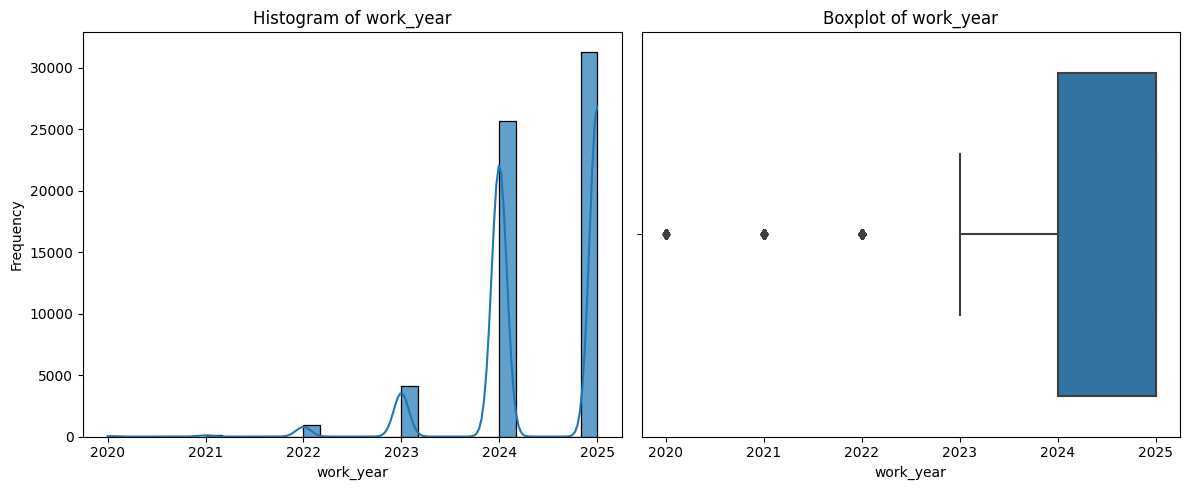

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


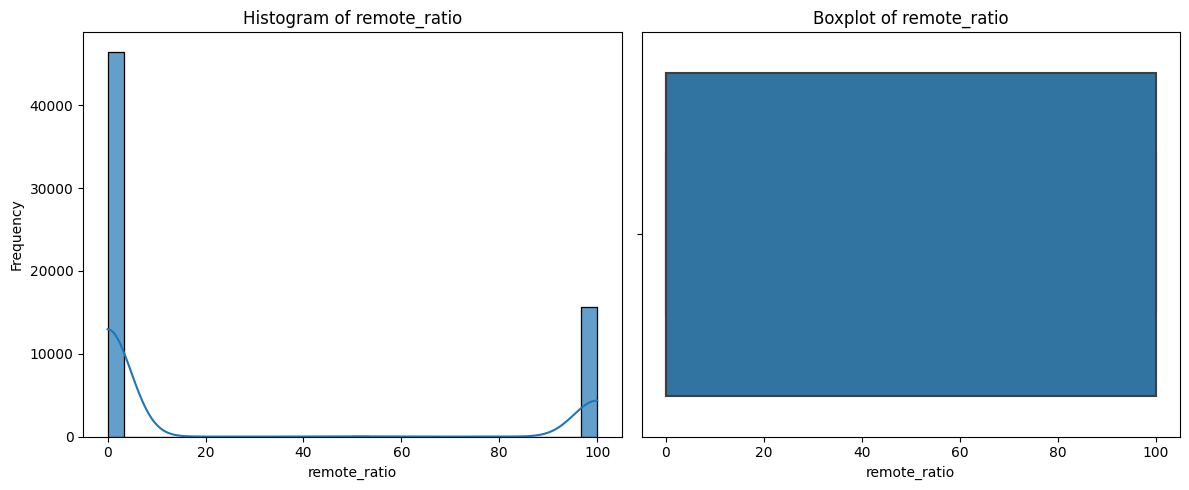

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


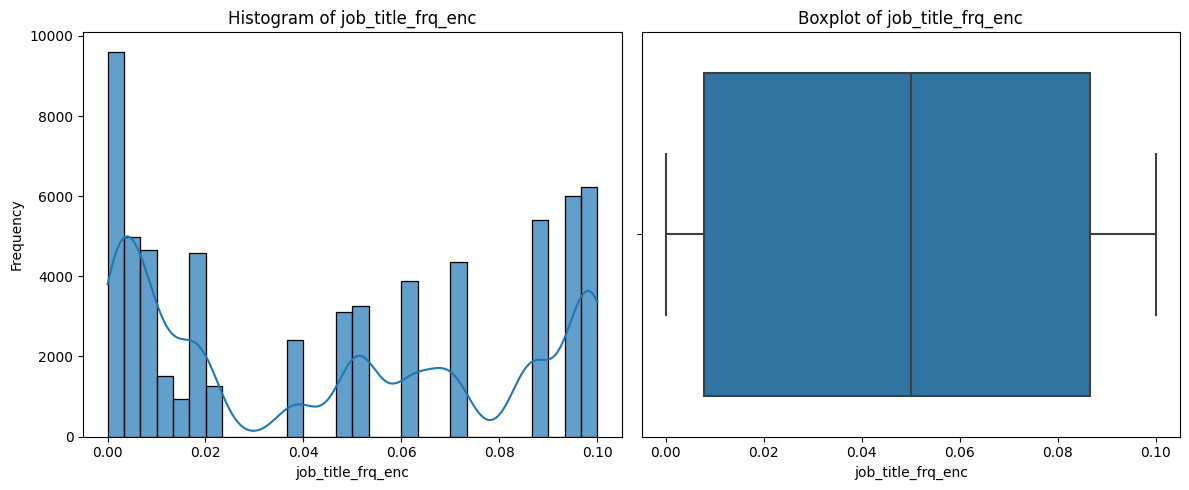

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


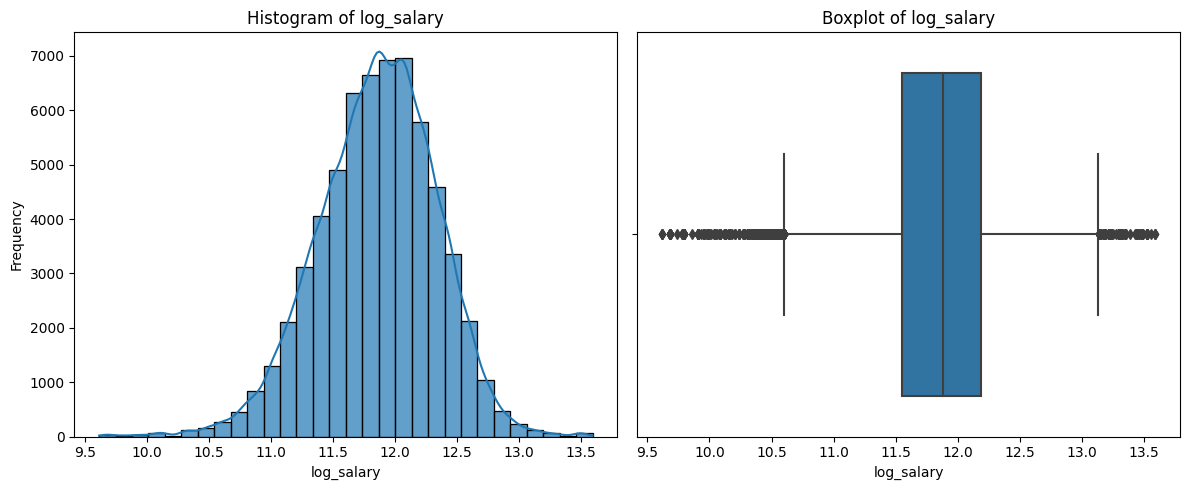

In [53]:
outlier_visulisation(sa_ml_reduced)

**Ouliter clipping**

In [54]:
def clip_outliers(df, target_col='log_salary', lower_quantile=0.01, upper_quantile=0.99, verbose=True):
    """
    Clips outliers in the target column and relevant numerical features using winsorization.

    Parameters:
    - df: pandas DataFrame
    - target_col: str, the name of the target column to clip (default: 'log_salary')
    - lower_quantile: float, lower quantile for clipping (default: 0.01)
    - upper_quantile: float, upper quantile for clipping (default: 0.99)
    - verbose: bool, if True, prints detailed clipping info

    Returns:
    - df: pandas DataFrame with outliers clipped
    """

    df = df.copy()  # Work on a copy to avoid modifying original data

    if verbose:
        print("Starting outlier handling (clipping/winsorization)...")

    # --- Clip target variable ---
    if target_col in df.columns:
        lower_bound_target = df[target_col].quantile(lower_quantile)
        upper_bound_target = df[target_col].quantile(upper_quantile)
        df[target_col] = np.clip(df[target_col], lower_bound_target, upper_bound_target)

        if verbose:
            print(f"Clipped '{target_col}': values below {lower_bound_target:.3f} set to {lower_bound_target:.3f}, "
                  f"values above {upper_bound_target:.3f} set to {upper_bound_target:.3f}.")
    else:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    # --- Clip other numerical features ---
    features_to_clip = [
        col for col in df.columns
        if df[col].dtype in ['int64', 'float64']
        and col != target_col
        and df[col].nunique() > 2
    ]

    if verbose:
        print(f"\nIdentifying numerical features in X for outlier clipping: {features_to_clip}")

    for col in features_to_clip:
        lower = df[col].quantile(lower_quantile)
        upper = df[col].quantile(upper_quantile)
        df[col] = np.clip(df[col], lower, upper)

        if verbose:
            print(f"  Clipped '{col}': values below {lower:.3f} set to {lower:.3f}, "
                  f"values above {upper:.3f} set to {upper:.3f}.")

    if verbose:
        print("\nOutlier handling (clipping) complete for relevant numerical columns.")

    return df

In [55]:
sa_ml_finalised = clip_outliers(sa_ml_reduced)

Starting outlier handling (clipping/winsorization)...
Clipped 'log_salary': values below 10.632 set to 10.632, values above 12.882 set to 12.882.

Identifying numerical features in X for outlier clipping: ['work_year', 'remote_ratio', 'job_title_frq_enc']
  Clipped 'work_year': values below 2022.000 set to 2022.000, values above 2025.000 set to 2025.000.
  Clipped 'remote_ratio': values below 0.000 set to 0.000, values above 100.000 set to 100.000.
  Clipped 'job_title_frq_enc': values below 0.000 set to 0.000, values above 0.100 set to 0.100.

Outlier handling (clipping) complete for relevant numerical columns.


## Data Spilt

In [56]:
# 1. Separate features (X) and target (y)
X = sa_ml_finalised.iloc[:, :-1]
y = sa_ml_finalised.iloc[:, -1]

# 2. Split data into training, validation, and testing sets (no stratify!)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Linear Regression

In [57]:
# Step 1: Feature Scaling
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data ONLY and transform both training and test data
# It's crucial to fit on training data only to prevent data leakage from test set.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform test set using scaler fitted on train
X_val_scaled = scaler.transform(X_val)   # Transform validation set as well

# Optional: Convert scaled arrays back to DataFrames for easier inspection
# (This step is not strictly necessary for model fitting but can be helpful)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print("Features scaled successfully.")

# Step 2: Model Training
lin_reg_model = LinearRegression()

# Train the model using the scaled training data
lin_reg_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

# Step 3: Prediction
# Make predictions on the scaled test set
log_preds = lin_reg_model.predict(X_test_scaled)

print("Predictions made on the test set.")

# Step 4: Revert Log Transformation and Evaluate
# Revert log1p() transformation for predictions
salary_preds = np.expm1(log_preds)

# Revert log1p() transformation for actual y_test values
true_salary = np.expm1(y_test)

Features scaled successfully.
Linear Regression model trained successfully.
Predictions made on the test set.


/tmp/ipykernel_13/200109098.py:35: RuntimeWarning: overflow encountered in expm1
  salary_preds = np.expm1(log_preds)


### Model Evaluation

In [58]:
# --- IMPORTANT: Inspect max/min values before np.expm1 ---
print(f"Max y_test (log scale): {y_test.max():.4f}")
print(f"Min y_test (log scale): {y_test.min():.4f}")
print(f"Max log_preds (log scale): {log_preds.max():.4f}")
print(f"Min log_preds (log scale): {log_preds.min():.4f}")

# Determine the clipping bounds based on the training data's y range
# It's safest to clip predictions to the range of log_salary you trained on
# or a slightly wider, but still finite, practical range.
lower_bound_for_expm1_clip = y_train.min()
upper_bound_for_expm1_clip = y_train.max()

# Clip both y_test and log_preds before np.expm1 to ensure no infinites
# (y_test should ideally already be clipped if your previous step worked on sa_ml_reduced)
clipped_log_preds = np.clip(log_preds, lower_bound_for_expm1_clip, upper_bound_for_expm1_clip)
clipped_y_test = np.clip(y_test, lower_bound_for_expm1_clip, upper_bound_for_expm1_clip)

# Revert log1p() transformation for predictions
salary_preds = np.expm1(clipped_log_preds)

# Revert log1p() transformation for actual y_test values
true_salary = np.expm1(clipped_y_test)

# Check for any remaining inf or NaN values in the final arrays
# This is a good sanity check after the clipping and expm1
if not np.all(np.isfinite(true_salary)):
    print("\nWARNING: 'true_salary' still contains non-finite values after clipping and expm1.")

if not np.all(np.isfinite(salary_preds)):
    print("\nWARNING: 'salary_preds' still contains non-finite values after clipping and expm1.")

# Calculate evaluation metrics on the original salary scale
mae = mean_absolute_error(true_salary, salary_preds)
mse = mean_squared_error(true_salary, salary_preds)
rmse = np.sqrt(mse) # Root Mean Squared Error for better interpretability
r2 = r2_score(true_salary, salary_preds)

print("\n--- Linear Regression Model Performance (on Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2 Score: {r2:.4f}")

Max y_test (log scale): 12.8823
Min y_test (log scale): 10.6320
Max log_preds (log scale): 34077198636876.9531
Min log_preds (log scale): -9143560446950.0605

--- Linear Regression Model Performance (on Test Set) ---
Mean Absolute Error (MAE): 50,775.03
Mean Squared Error (MSE): 4,596,321,126.57
Root Mean Squared Error (RMSE): 67,796.17
R2 Score: 0.0942


## Ramdom Forest Regressor

In [59]:
# Initialize a Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200], # Start with 100, 200. Can go higher (e.g., 500, 1000)
    'max_features': [0.8, 1.0], # Percentage of features to consider for each split. 'auto' (sqrt) is default.
                                 # 0.8 means 80% of features, 1.0 means all features (Bagging).
    'max_depth': [None, 10, 20], # None means nodes are expanded until all leaves are pure or contain min_samples_split samples.
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5, # Using 5-fold cross-validation on the training data (X_train, y_train)
    n_jobs=-1, # n_jobs: Number of CPU cores to use (-1 means use all available cores)
    verbose=2, # Controls the verbosity of the output. 2 means prints detailed progress.
    scoring='neg_mean_squared_error' # Optimize for RMSE (neg_mse for GridSearchCV)
)

print("Starting GridSearchCV for Random Forest...")
# Fit GridSearchCV on the training data (X_train, y_train)
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {grid_search.best_score_:.4f}")

# Get the best model found by GridSearchCV
best_rf_model = grid_search.best_estimator_
print("\nBest Random Forest model extracted.")

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

GridSearchCV complete.
Best parameters found: {'max_depth': 20, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score (neg_mean_squared_error): -0.1518

Best Random Forest model extracted.


In [60]:
log_preds_val = best_rf_model.predict(X_val)
salary_preds_val = np.expm1(np.clip(log_preds_val, 0, np.expm1(y_train.max() + 2)))
true_salary_val = np.expm1(y_val)

# Evaluate on validation set
mae_val = mean_absolute_error(true_salary_val, salary_preds_val)
r2_val = r2_score(true_salary_val, salary_preds_val)

print(f"\nValidation MAE: {mae_val:,.2f}")
print(f"Validation R²: {r2_val:.4f}")


Validation MAE: 47,420.28
Validation R²: 0.2172


In [61]:
# Step 2: Prediction on the Test Set
# Make predictions on the test set using the best model
log_preds_rf = best_rf_model.predict(X_test)

print("Predictions made on the test set with the best Random Forest model.")

# Step 3: Revert Log Transformation and Evaluate
# Revert log1p() transformation for predictions
# Use np.expm1() to get back to the original salary scale
salary_preds_rf = np.expm1(log_preds_rf)

# Revert log1p() transformation for actual y_test values
true_salary_rf = np.expm1(y_test)

# Ensure no infinites or NaNs were produced by expm1 (good practice)
# This was handled in the last step of the previous session but good to re-confirm
salary_preds_rf = np.clip(salary_preds_rf, 0, np.expm1(y_train.max() + 2))

# Calculate evaluation metrics on the original salary scale
mae_rf = mean_absolute_error(true_salary_rf, salary_preds_rf)
mse_rf = mean_squared_error(true_salary_rf, salary_preds_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(true_salary_rf, salary_preds_rf)

print("\n--- Random Forest Regressor Model Performance (on Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae_rf:,.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Predictions made on the test set with the best Random Forest model.

--- Random Forest Regressor Model Performance (on Test Set) ---
Mean Absolute Error (MAE): 46,597.14
Mean Squared Error (MSE): 3,885,583,443.55
Root Mean Squared Error (RMSE): 62,334.45
R2 Score: 0.2342


In [62]:
# Step 4: Feature Importance (Specific to Tree-based Models)
# Random Forest models provide feature importances, indicating how much each feature
# contributed to the model's predictions.

feature_importances = best_rf_model.feature_importances_
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 15 Feature Importances ---")
print(features_df.head(15))


--- Top 15 Feature Importances ---
                   Feature  Importance
111      job_title_frq_enc    0.422611
5      experience_level_SE    0.191924
3      experience_level_EX    0.100698
4      experience_level_MI    0.085086
89   employee_residence_US    0.052798
0                work_year    0.040722
1             remote_ratio    0.033853
7       employment_type_FT    0.013623
20   employee_residence_CA    0.010915
9           company_size_M    0.009733
8       employment_type_PT    0.006424
35   employee_residence_GB    0.005264
61   employee_residence_MX    0.004478
47   employee_residence_IN    0.003382
14   employee_residence_AU    0.003256


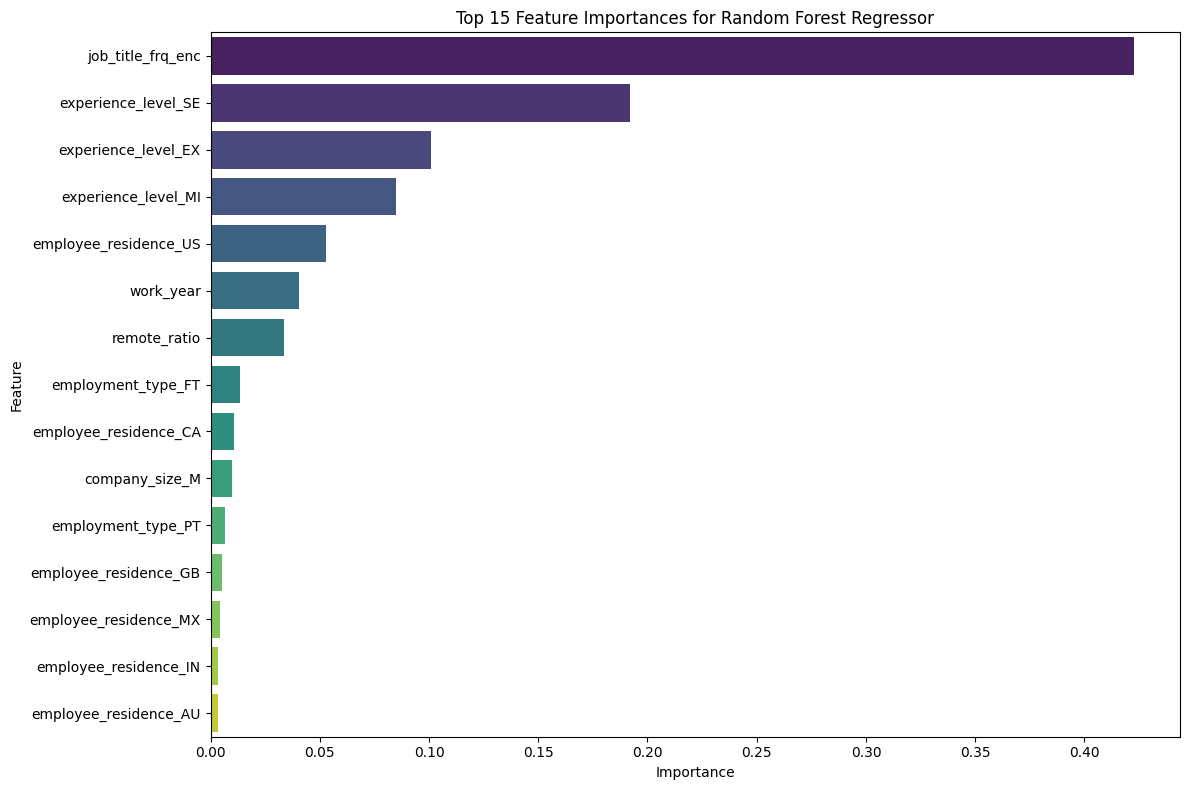

In [63]:
# Plotting Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances for Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Random Forest Regressor With A Major Transformation

## Data Preprocessing: Major transformation

In [64]:
def preprocess(filename = "house_price"):
    """prepares and transforms dataframe"""

    # change data types
    dtype_mapper = {"experience_level" : "category",
                    "employment_type" : "category",
                    "job_title" : "string",
                    "salary_currency" : "category",
                    "employee_residence" : "string",
                    "company_location" : "string",
                    "company_size" : "category"}
    
    # read the data file
    df = (pd.read_csv(filename, dtype=dtype_mapper)
        .drop("salary", axis = 1))

    # Standardizes currency values
    df["salary_currency"] = df["salary_currency"].str.strip().str.upper()

    # Keeps only rows where currency is USD
    df = df[df["salary_currency"] == "USD"]

    # removes duplicated rows
    df = df.drop_duplicates()

    # drop a column
    df.drop("salary_currency", axis=1, inplace=True)
    
    # Feature Engineering (Binary features)
    # create a binary feature: 1 for fully remote jobs, 0 otherwise
    df["is_fully_remote"] = (df["remote_ratio"] == 100).astype(int)

    # help the model understand whether the employee is working from their home country.
    df["is_domestic"] = (df["employee_residence"] == df["company_location"]).astype(int)

    # Feature Engineering for Job Title Grouping
    def assign_job_category(job_title):
        """group job titles that share similar role to reduce the number of unique values in the column."""
        job_title = str(job_title).lower() # Ensure string and lowercase for consistent matching
    
        # Define your categories and associated keywords (ordered by specificity)
        # More specific roles should be checked first
        if 'principal data scientist' in job_title or 'staff data scientist' in job_title or 'lead data scientist' in job_title:
            return 'Data Scientist (Senior/Lead)'
        elif 'principal machine learning engineer' in job_title or 'lead machine learning engineer' in job_title or 'mlops' in job_title or 'machine learning platform' in job_title:
            return 'ML/AI Engineer (Senior/Lead)'
        elif 'principal data engineer' in job_title or 'lead data engineer' in job_title or 'data platform engineer' in job_title:
            return 'Data Engineer (Senior/Lead)'
        elif 'principal data architect' in job_title or 'cloud architect' in job_title or 'enterprise data architect' in job_title:
            return 'Data/Cloud Architect'
    
        # Core Roles
        if 'data scientist' in job_title or 'applied scientist' in job_title or 'cientista de dados' in job_title:
            return 'Data Scientist'
        elif 'machine learning engineer' in job_title or 'ml engineer' in job_title or 'ai engineer' in job_title or 'deep learning engineer' in job_title or 'computer vision' in job_title or 'nlp engineer' in job_title or 'prompt engineer' in job_title or 'genai' in job_title or 'robotics engineer' in job_title:
            return 'ML/AI Engineer'
        elif 'data engineer' in job_title or 'big data' in job_title or 'etl' in job_title or 'data integration' in job_title or 'data pipeline' in job_title or 'azure data engineer' in job_title or 'cloud data engineer' in job_title:
            return 'Data Engineer'
        elif 'data analyst' in job_title or 'analyst' in job_title or 'business intelligence' in job_title or 'bi analyst' in job_title or 'analytics engineer' in job_title or 'power bi' in job_title or 'tableau developer' in job_title or 'insight analyst' in job_title:
            return 'Data Analyst/BI'
        elif 'software engineer' in job_title or 'developer' in job_title or 'full stack' in job_title or 'backend engineer' in job_title or 'web developer' in job_title or 'java developer' in job_title or 'python developer' in job_title:
            return 'Software/Developer'
        elif 'researcher' in job_title or 'research scientist' in job_title or 'postdoctoral' in job_title or 'quantitative researcher' in job_title:
            return 'Researcher'
        elif 'data architect' in job_title or 'solution architect' in job_title or 'solutions architect' in job_title:
            return 'Data/Solution Architect'
    
        # Management/Leadership (General)
        elif 'director' in job_title or 'head of' in job_title or 'manager' in job_title or 'lead' in job_title or 'tech lead' in job_title:
            return 'Manager/Lead/Director'
    
        # Data Governance/Quality
        elif 'data governance' in job_title or 'data quality' in job_title or 'data management' in job_title or 'data steward' in job_title or 'master data management' in job_title:
            return 'Data Governance/Quality/Mgmt'
    
        # Other Common Roles
        elif 'consultant' in job_title:
            return 'Consultant'
        elif 'devops' in job_title:
            return 'DevOps Engineer'
        elif 'qa engineer' in job_title:
            return 'QA Engineer'
        elif 'product manager' in job_title or 'product owner' in job_title:
            return 'Product Manager/Owner'
        elif 'sales' in job_title or 'business development' in job_title:
            return 'Sales/BizDev'
        elif 'engineer' in job_title: # Broad engineer last
            return 'Engineer (General)'
        
        # Catch-all if nothing specific is found
        return 'Other/Uncategorized'

    df["job_category"] = df["job_title"].apply(assign_job_category)
    
    # OneHotEncoding - Adjust the list of categorical columns to include 'job_category'
    # and remove 'job_title' from this list as it will be dropped.
    categorical_cols = [
        "experience_level",
        "employment_type",
        "company_size",
        "employee_residence",
        "company_location",
        "job_category" # NEW FEATURE HERE
    ]
    
    # Set up the encoder
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first').set_output(transform="pandas")
    
    # Fit and transform the categorical columns
    ohe_transformed = ohe.fit_transform(df[categorical_cols])
    
    # Combine with original dataframe (drop the original categorical columns, including the new 'job_category'
    # and the old 'job_title' which is no longer needed after deriving 'job_category')
    df = pd.concat([df.drop(columns=categorical_cols + ["job_title"]), ohe_transformed], axis=1)

    # Reorder the column for ML (moving 'salary_in_usd' to last if it still exists)
    if "salary_in_usd" in df.columns:
        cols = [col for col in df.columns if col != "salary_in_usd"]
        cols.append("salary_in_usd")
        df = df[cols]
    else:
        print("Error: 'salary_in_usd' column not found in DataFrame after preprocessing.")

    # Log-transform the target salary column
    df["log_salary"] = np.log1p(df["salary_in_usd"])
    
    # Drop the original salary column to avoid leakage and simplify correlation analysis
    df.drop("salary_in_usd", axis=1, inplace=True)

    # drop duplicated rows (if any new duplicates were created by feature engineering, unlikely but safe)
    df.drop_duplicates(inplace = True)

    print("\nPreprocessing complete!")
    print(f"Final DataFrame: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

    return df

sa_ml_transformed = preprocess(filename="/kaggle/input/salaries-for-data-science-jobs/salaries.csv")
sa_ml_transformed.sample(5)


Preprocessing complete!
Final DataFrame: 51,715 rows × 204 columns


,work_year,remote_ratio,is_fully_remote,is_domestic,experience_level_EX,experience_level_MI,experience_level_SE,employment_type_FL,employment_type_FT,employment_type_PT,...,job_category_ML/AI Engineer,job_category_ML/AI Engineer (Senior/Lead),job_category_Manager/Lead/Director,job_category_Other/Uncategorized,job_category_Product Manager/Owner,job_category_QA Engineer,job_category_Researcher,job_category_Sales/BizDev,job_category_Software/Developer,log_salary
3402,2025,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.863589
25079,2025,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.418281
57771,2025,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.560248
90737,2024,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12.387565
73550,2024,0,0,1,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.055256


## Major change explained:

410 unique values for 'job_title' is a lot. Frequency encoding,that I did earlier, helped reduce cardinality but didn't capture the semantic meaning or similarity between titles. For example, "Data Scientist" and "Applied Scientist" are very similar roles, but frequency encoding would treat them as completely distinct based solely on their count. That's why I implemented a nested function keyword-based grouping inside the preprocessing data function to group job titles that share the same key word together to hopefully get better predictive power for a model like Random Forest.

Since the dataset has been transformed with a major changes, and it just like a new dataset. Therefore, I need to do feature selection, drop some features with "inf" values using VIF, and outlier clipping all over again.

### Feature selection

In [65]:
sa_ml_transformed_reduced, corr_pairs, dropped_features = drop_highly_correlated_features(sa_ml_transformed, threshold=0.9, verbose=True)

Correlation threshold = 0.9
 Highly correlated feature pairs (|corr| > 0.9):
- remote_ratio and is_fully_remote
- employee_residence_AM and company_location_AM
- employee_residence_AR and company_location_AR
- employee_residence_AS and company_location_BS
- employee_residence_AT and company_location_AT
- employee_residence_AU and company_location_AU
- employee_residence_BA and company_location_BA
- employee_residence_BE and company_location_BE
- employee_residence_BR and company_location_BR
- employee_residence_CA and company_location_CA
- employee_residence_CH and company_location_CH
- employee_residence_CL and company_location_CL
- employee_residence_CO and company_location_CO
- employee_residence_CR and company_location_CR
- employee_residence_DE and company_location_DE
- employee_residence_DK and company_location_DK
- employee_residence_EC and company_location_EC
- employee_residence_EG and company_location_EG
- employee_residence_ES and company_location_ES
- employee_residence_FI 

## VIF

In [66]:
sa_ml_transformed_reduced, vif_report = remove_multicollinear_features(sa_ml_transformed_reduced, vif_threshold=np.inf, verbose=True)

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



 VIF Data:
                             Feature           VIF
0                              const  8.700740e+06
1                          work_year  1.122473e+00
2                       remote_ratio  1.038973e+00
3                        is_domestic  1.900639e+00
4                experience_level_EX  1.517170e+00
..                               ...           ...
137         job_category_QA Engineer  1.105658e+00
138          job_category_Researcher  3.099173e+00
139        job_category_Sales/BizDev  1.064204e+00
140  job_category_Software/Developer  7.734301e+00
141                       log_salary  1.331493e+00

[142 rows x 2 columns]

 Dropped multicollinear features: ['employee_residence_AS', 'employee_residence_BM', 'employee_residence_CD', 'employee_residence_DZ', 'employee_residence_JE', 'employee_residence_RW', 'company_location_BS', 'company_location_CD', 'company_location_CN', 'company_location_DZ']


## Outlier clipping

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


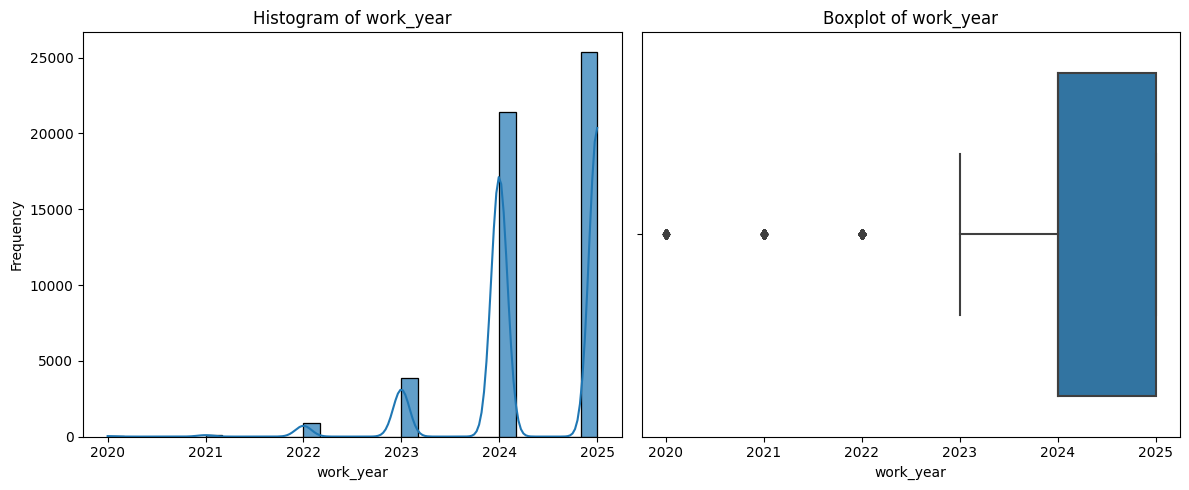

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


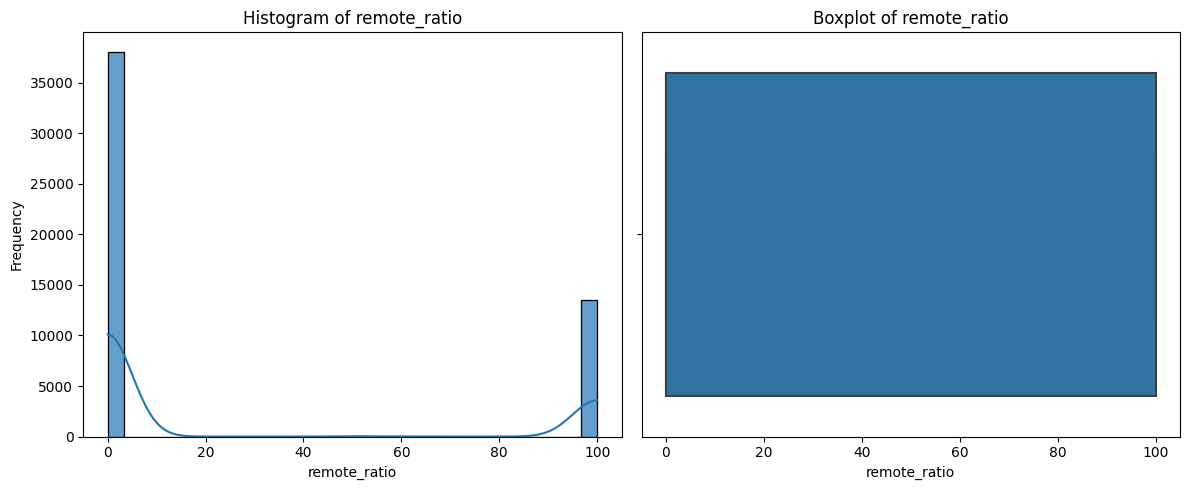

Histogram for data distribution and boxplot for detecting outliers


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


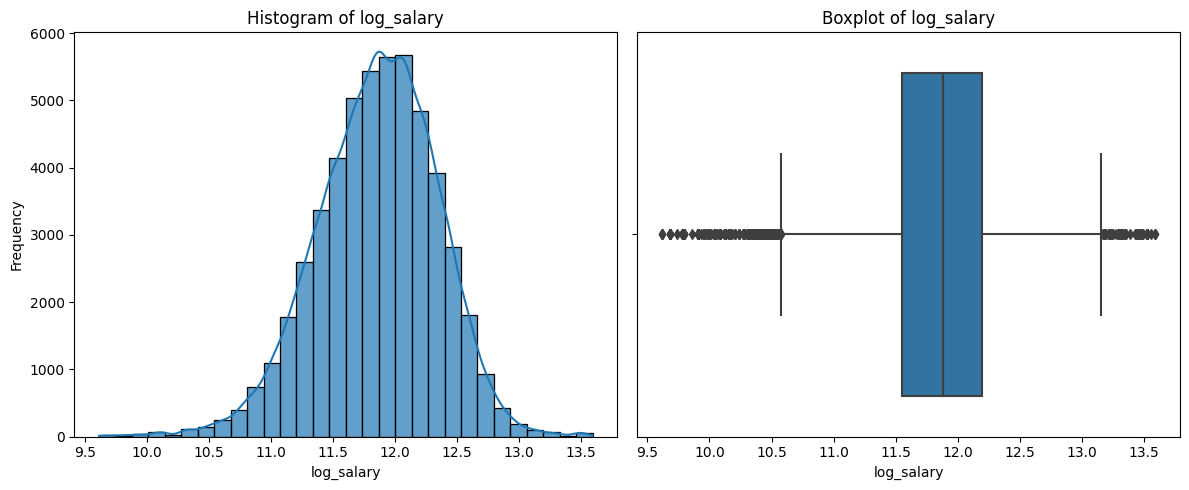

In [67]:
outlier_visulisation(sa_ml_transformed_reduced)

**Clip the outliers**

In [68]:
sa_ml_transformed_reduced_finalised = clip_outliers(sa_ml_transformed_reduced)

Starting outlier handling (clipping/winsorization)...
Clipped 'log_salary': values below 10.597 set to 10.597, values above 12.897 set to 12.897.

Identifying numerical features in X for outlier clipping: ['work_year', 'remote_ratio']
  Clipped 'work_year': values below 2022.000 set to 2022.000, values above 2025.000 set to 2025.000.
  Clipped 'remote_ratio': values below 0.000 set to 0.000, values above 100.000 set to 100.000.

Outlier handling (clipping) complete for relevant numerical columns.


## Data Split + Grid Search

In [69]:
# Data Split
# 1. Separate features (X) and target (y)
X = sa_ml_transformed_reduced_finalised.iloc[:, :-1]
y = sa_ml_transformed_reduced_finalised.iloc[:, -1]

# 2. Split data into training, validation, and testing sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Grid Search
# Step 1: Hyperparameter Tuning (Using GridSearchCV as an example)

# Initialize a Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200], # Start with 100, 200. Can go higher (e.g., 500, 1000)
    'max_features': [0.8, 1.0], # Percentage of features to consider for each split. 'auto' (sqrt) is default.
                                 # 0.8 means 80% of features, 1.0 means all features (Bagging).
                                 # Can also use 'sqrt' or 'log2'.
    'max_depth': [None, 10, 20], # None means nodes are expanded until all leaves are pure or contain min_samples_split samples.
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5, # Using 5-fold cross-validation on the training data (X_train, y_train)
    n_jobs=-1, # n_jobs: Number of CPU cores to use (-1 means use all available cores)
    verbose=2, # Controls the verbosity of the output. 2 means prints detailed progress.
    scoring='neg_mean_squared_error' # Optimize for RMSE (neg_mse for GridSearchCV)
)

print("Starting GridSearchCV for Random Forest...")
# Fit GridSearchCV on the training data (X_train, y_train)
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {grid_search.best_score_:.4f}")

# Get the best model found by GridSearchCV
best_rf_model = grid_search.best_estimator_
print("\nBest Random Forest model extracted.")

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   8.2s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  16.7s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   7.6s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   7.9s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  15.6s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   7.4s
[CV] END max_depth=None, max_features=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   7.7s
[CV] END max_depth=None, max_features=0.8, min_s

## Validation thing

In [70]:
log_preds_val = best_rf_model.predict(X_val)
salary_preds_val = np.expm1(np.clip(log_preds_val, 0, np.expm1(y_train.max() + 2)))
true_salary_val = np.expm1(y_val)

# Evaluate on validation set
mae_val = mean_absolute_error(true_salary_val, salary_preds_val)
r2_val = r2_score(true_salary_val, salary_preds_val)

print(f"\nValidation MAE: {mae_val:,.2f}")
print(f"Validation R²: {r2_val:.4f}")


Validation MAE: 49,704.20
Validation R²: 0.1677


## Prediction results

In [71]:
# Step 2: Prediction on the Test Set
# Make predictions on the test set using the best model
log_preds_rf = best_rf_model.predict(X_test)

print("Predictions made on the test set with the best Random Forest model.")

# Step 3: Revert Log Transformation and Evaluate
# Revert log1p() transformation for predictions
# Use np.expm1() to get back to the original salary scale
salary_preds_rf = np.expm1(log_preds_rf)

# Revert log1p() transformation for actual y_test values
true_salary_rf = np.expm1(y_test)

# Ensure no infinites or NaNs were produced by expm1 (good practice)
# This was handled in the last step of the previous session but good to re-confirm
# A simple clip to a very high, but finite, value can prevent inf if predictions are wild
salary_preds_rf = np.clip(salary_preds_rf, 0, np.expm1(y_train.max() + 2)) # Cap at max of train log_salary + a bit, then expm1

# Calculate evaluation metrics on the original salary scale
mae_rf = mean_absolute_error(true_salary_rf, salary_preds_rf)
mse_rf = mean_squared_error(true_salary_rf, salary_preds_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(true_salary_rf, salary_preds_rf)

print("\n--- Random Forest Regressor Model Performance (on Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae_rf:,.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Predictions made on the test set with the best Random Forest model.

--- Random Forest Regressor Model Performance (on Test Set) ---
Mean Absolute Error (MAE): 49,347.94
Mean Squared Error (MSE): 4,394,924,197.98
Root Mean Squared Error (RMSE): 66,294.22
R2 Score: 0.1730


# Notebook summary


This notebook offers a comprehensive Exploratory Data Analysis (EDA) focused on the data science job market. It's structured into **two primary sections**. The first section performs a **descriptive analysis**, uncovering insights related to global salary trends by region and work experience, and provides career advice for job seekers. The second section delves into **predictive modeling**, employing techniques such as Linear Regression and Random Forest Regressor. This part meticulously walks through **rigorous data preprocessing, advanced feature engineering (e.g., job title grouping), feature selection, and methods to address multicollinearity**—all aimed at optimizing the predictive performance of the models.

# Model summary

1. **Linear regression (baseline)**
- Mean Absolute Error (MAE): 50,775.03
- Mean Squared Error (MSE): 4,596,321,126.57
- Root Mean Squared Error (RMSE): 67,796.17
- R2 Score: 0.0942

2. **Random Forest Regressor**
- Mean Absolute Error (MAE): 46,597.14
- Mean Squared Error (MSE): 3,885,583,443.55
- Root Mean Squared Error (RMSE): 62,334.45
- R2 Score: 0.2342

3. **Random Forest Regressor (with a major change in the data preprocessing step)**
- Mean Absolute Error (MAE): 49,347.94
- Mean Squared Error (MSE): 4,394,924,197.98
- Root Mean Squared Error (RMSE): 66,294.22
- R2 Score: 0.1730